In [1]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import re
import numpy as np
import sys

sys.path.insert(0, "../Modules")

from utils import describe_dataframe

pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [2]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/Grid Level/data'

In [3]:
NUTS2 = 'Thrace'
YEAR = '2024'

In [4]:
df = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled.csv', encoding=enc)

C:\Users\dimit\AppData\Local\Temp\ipykernel_7556\2622664866.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled.csv', encoding=enc)


In [5]:
df.head()

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,indices_image_date.1,indices_lat.1,indices_lon.1,dt_placement_minus_1,dt_placement_minus_1_avail,rainfall_new
0,23.65882,41.33542,0,2024-06-02,EL51,2024,6,2024-06-01,41.333732,23.659379,0.721511,0.274496,-0.604530,-0.274496,0.731577,0.283857,-0.610010,-0.283857,0.037083,0.028736,0.035048,0.028736,2024-06-02,41.333732,23.659379,14953.0,14503.0,2024-06-02,41.350189,23.650108,2024-06-01,2024-06-01,0.0
1,23.65882,41.33542,0,2024-06-03,EL51,2024,6,2024-06-01,41.333732,23.659379,0.721511,0.274496,-0.604530,-0.274496,0.731577,0.283857,-0.610010,-0.283857,0.037083,0.028736,0.035048,0.028736,2024-06-03,41.333732,23.659379,14499.0,14503.0,2024-06-02,41.350189,23.650108,2024-06-02,2024-06-02,0.0
2,23.65882,41.33542,0,2024-06-04,EL51,2024,6,2024-06-01,41.333732,23.659379,0.721511,0.274496,-0.604530,-0.274496,0.731577,0.283857,-0.610010,-0.283857,0.037083,0.028736,0.035048,0.028736,2024-06-04,41.333732,23.659379,15059.0,14567.0,2024-06-02,41.350189,23.650108,2024-06-03,2024-06-02,0.0
3,23.65882,41.33542,0,2024-06-05,EL51,2024,6,2024-06-01,41.333732,23.659379,0.721511,0.274496,-0.604530,-0.274496,0.731577,0.283857,-0.610010,-0.283857,0.037083,0.028736,0.035048,0.028736,2024-06-05,41.333732,23.659379,14833.0,14567.0,2024-06-02,41.350189,23.650108,2024-06-04,2024-06-02,0.0
4,23.65882,41.33542,0,2024-06-06,EL51,2024,6,2024-06-06,41.333732,23.659379,0.693297,0.273188,-0.586919,-0.273188,0.703577,0.283014,-0.594945,-0.283014,0.039954,0.029496,0.035281,0.029496,2024-06-06,41.333732,23.659379,14980.0,14493.0,2024-06-02,41.350189,23.650108,2024-06-05,2024-06-02,0.0


<Axes: >

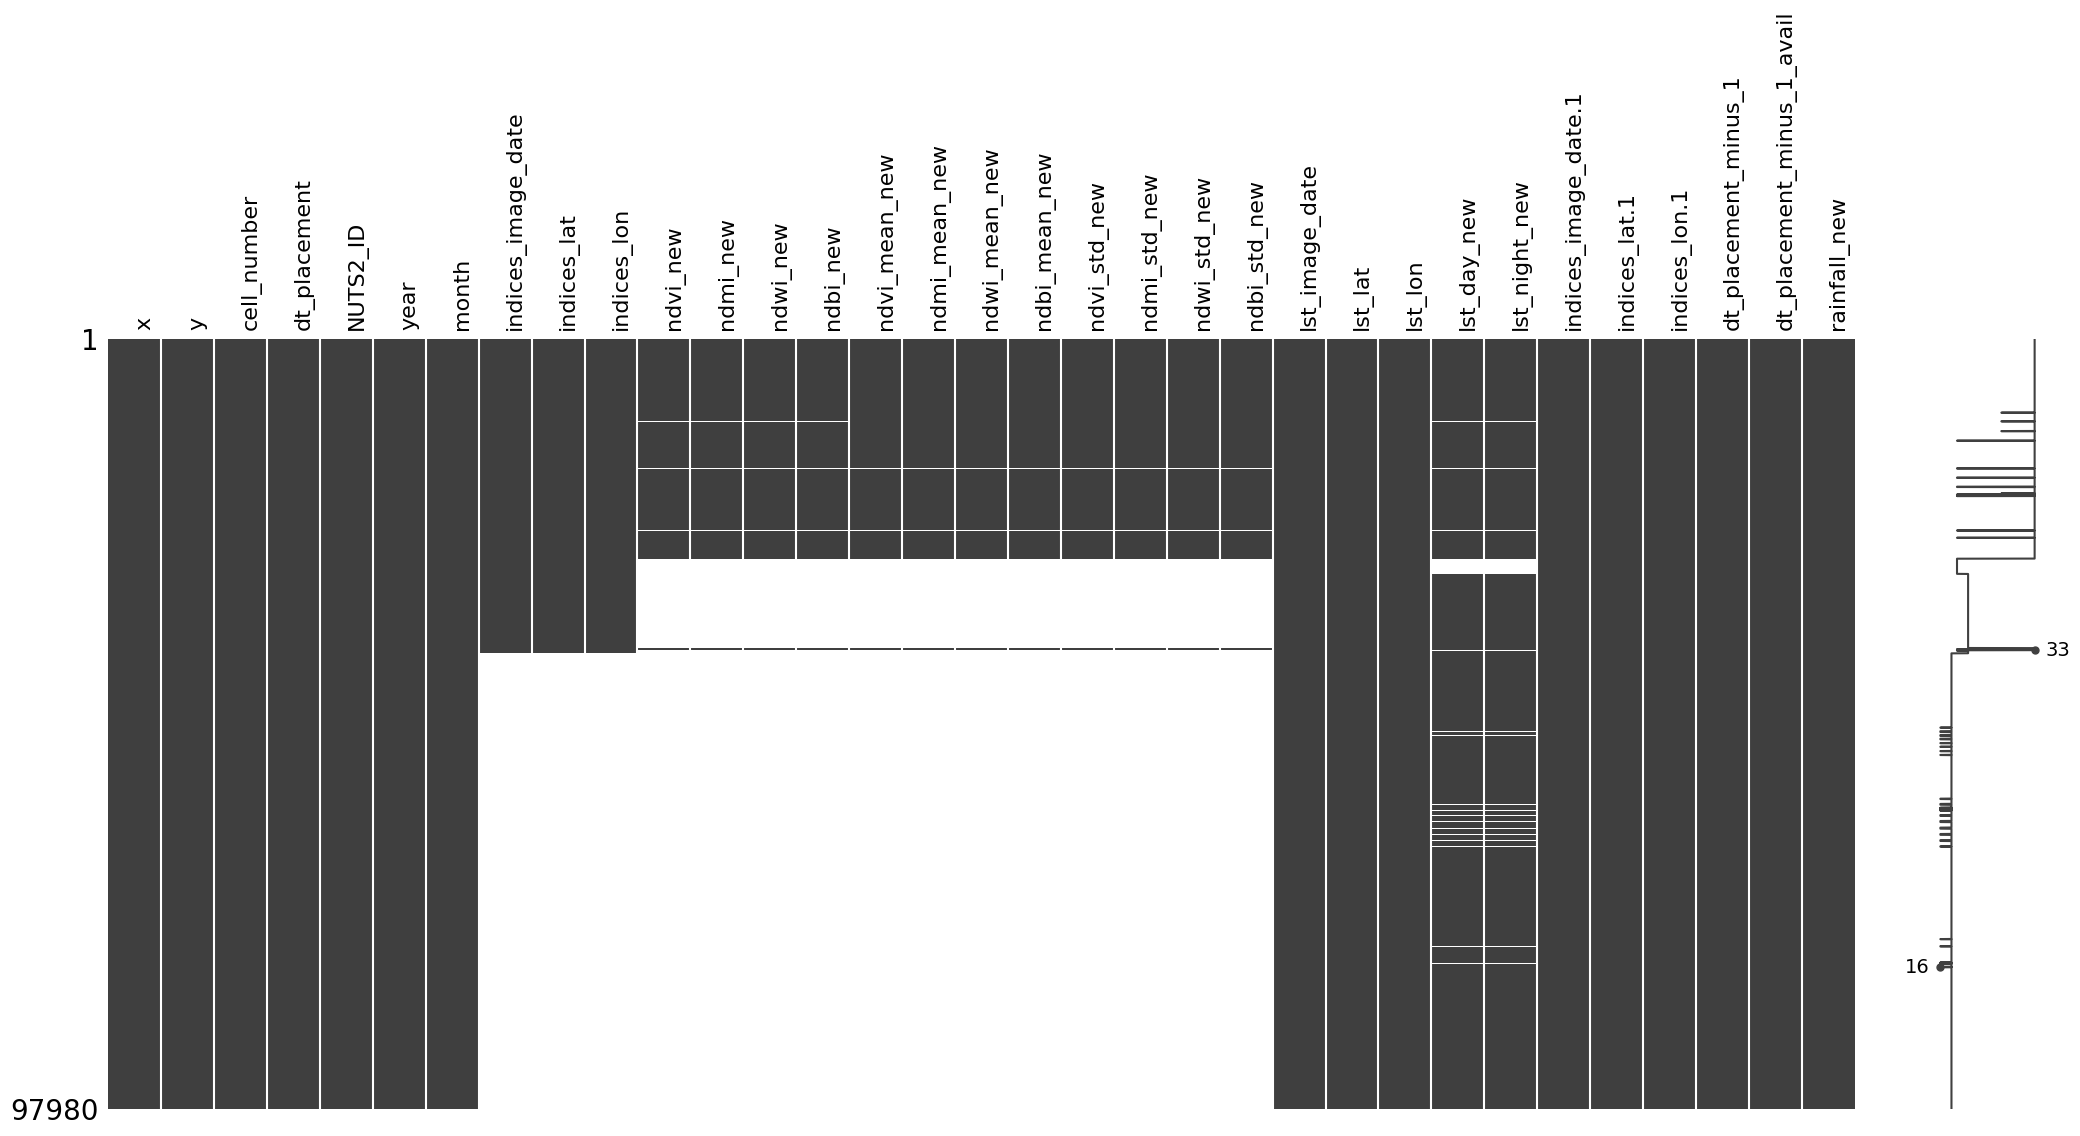

In [6]:
msno.matrix(df, label_rotation=90)

In [7]:
df.drop(['indices_lat', 'indices_lon', 'lst_lat', 'lst_lon', 'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_1'], axis = 1, inplace=True)

In [8]:
df.rename(columns={"dt_placement_minus_1_avail" : "rainfall_image_date"}, errors="raise", inplace=True)

In [9]:
df = df.rename(columns=lambda x: re.sub('_new', '', x))

In [10]:
df['dt_placement']= pd.to_datetime(df['dt_placement'])
df['indices_image_date']= pd.to_datetime(df['indices_image_date'])
df['lst_image_date']= pd.to_datetime(df['lst_image_date'])
df['rainfall_image_date']= pd.to_datetime(df['rainfall_image_date'])

In [11]:
df

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,indices_image_date,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_day,lst_night,rainfall_image_date,rainfall
0,23.65882,41.33542,0,2024-06-02,EL51,2024,6,2024-06-01,0.721511,0.274496,-0.604530,-0.274496,0.731577,0.283857,-0.610010,-0.283857,0.037083,0.028736,0.035048,0.028736,2024-06-02,14953.0,14503.0,2024-06-01,0.0
1,23.65882,41.33542,0,2024-06-03,EL51,2024,6,2024-06-01,0.721511,0.274496,-0.604530,-0.274496,0.731577,0.283857,-0.610010,-0.283857,0.037083,0.028736,0.035048,0.028736,2024-06-03,14499.0,14503.0,2024-06-02,0.0
2,23.65882,41.33542,0,2024-06-04,EL51,2024,6,2024-06-01,0.721511,0.274496,-0.604530,-0.274496,0.731577,0.283857,-0.610010,-0.283857,0.037083,0.028736,0.035048,0.028736,2024-06-04,15059.0,14567.0,2024-06-02,0.0
3,23.65882,41.33542,0,2024-06-05,EL51,2024,6,2024-06-01,0.721511,0.274496,-0.604530,-0.274496,0.731577,0.283857,-0.610010,-0.283857,0.037083,0.028736,0.035048,0.028736,2024-06-05,14833.0,14567.0,2024-06-02,0.0
4,23.65882,41.33542,0,2024-06-06,EL51,2024,6,2024-06-06,0.693297,0.273188,-0.586919,-0.273188,0.703577,0.283014,-0.594945,-0.283014,0.039954,0.029496,0.035281,0.029496,2024-06-06,14980.0,14493.0,2024-06-02,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97975,26.58397,41.49712,3261,2024-07-01,EL51,2024,7,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-07-01,15641.0,14671.0,2024-06-02,0.0
97976,26.60756,41.35339,3262,2024-07-01,EL51,2024,7,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-07-01,15733.0,14715.0,2024-06-02,0.0
97977,26.60756,41.37135,3263,2024-07-01,EL51,2024,7,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-07-01,15712.0,14746.0,2024-06-02,0.0
97978,26.60756,41.38932,3264,2024-07-01,EL51,2024,7,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-07-01,15713.0,14719.0,2024-06-02,0.0


<Axes: >

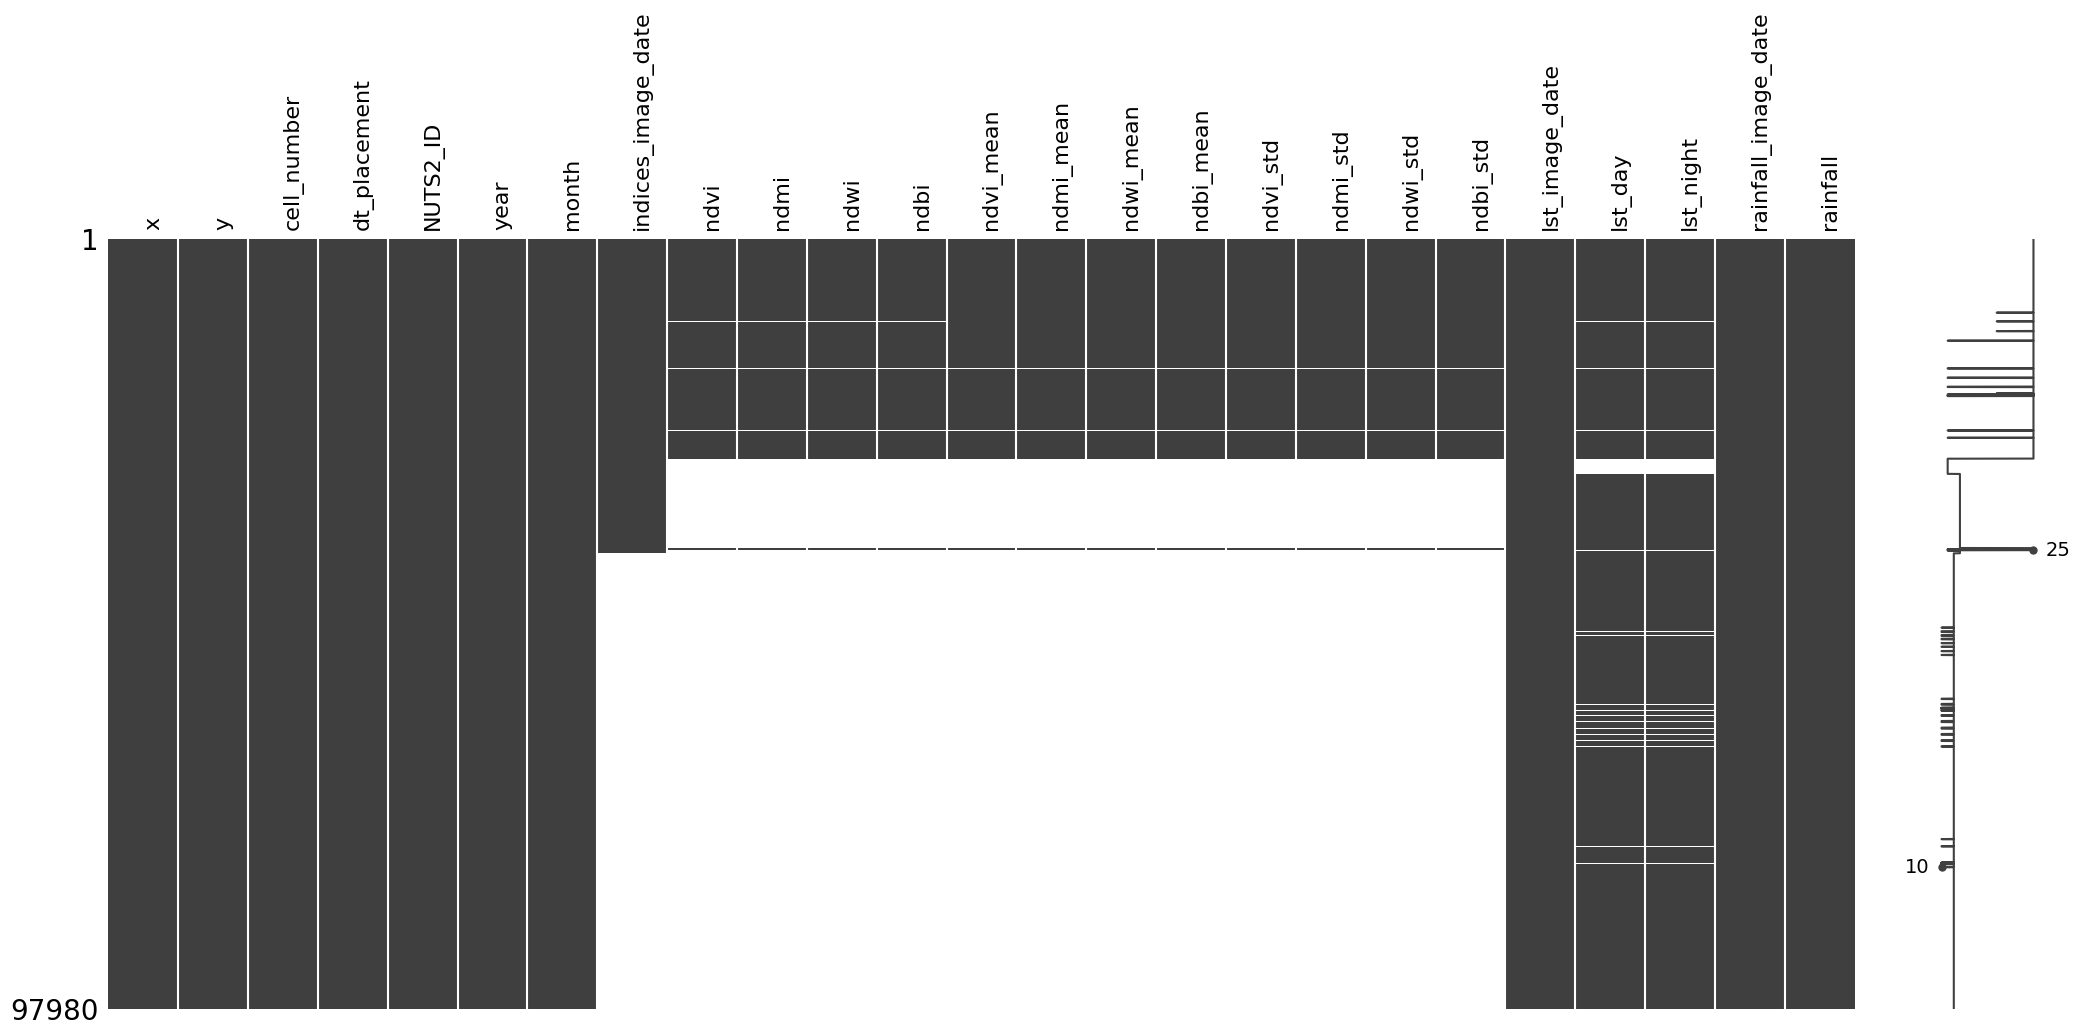

In [12]:
msno.matrix(df, label_rotation=90)

In [13]:
df2 = df.copy()

In [14]:
indices_mask = df2['indices_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=7))
lst_mask = df2['lst_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))
rainfall_mask = df2['rainfall_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))

indices_columns = ['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean',
                  'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std']

lst_columns = ['lst_day', 'lst_night']

rainfall_columns = ['rainfall']

df2.loc[indices_mask, indices_columns] = np.nan
df2.loc[lst_mask, lst_columns] = np.nan
df2.loc[rainfall_mask, rainfall_columns] = np.nan

<Axes: >

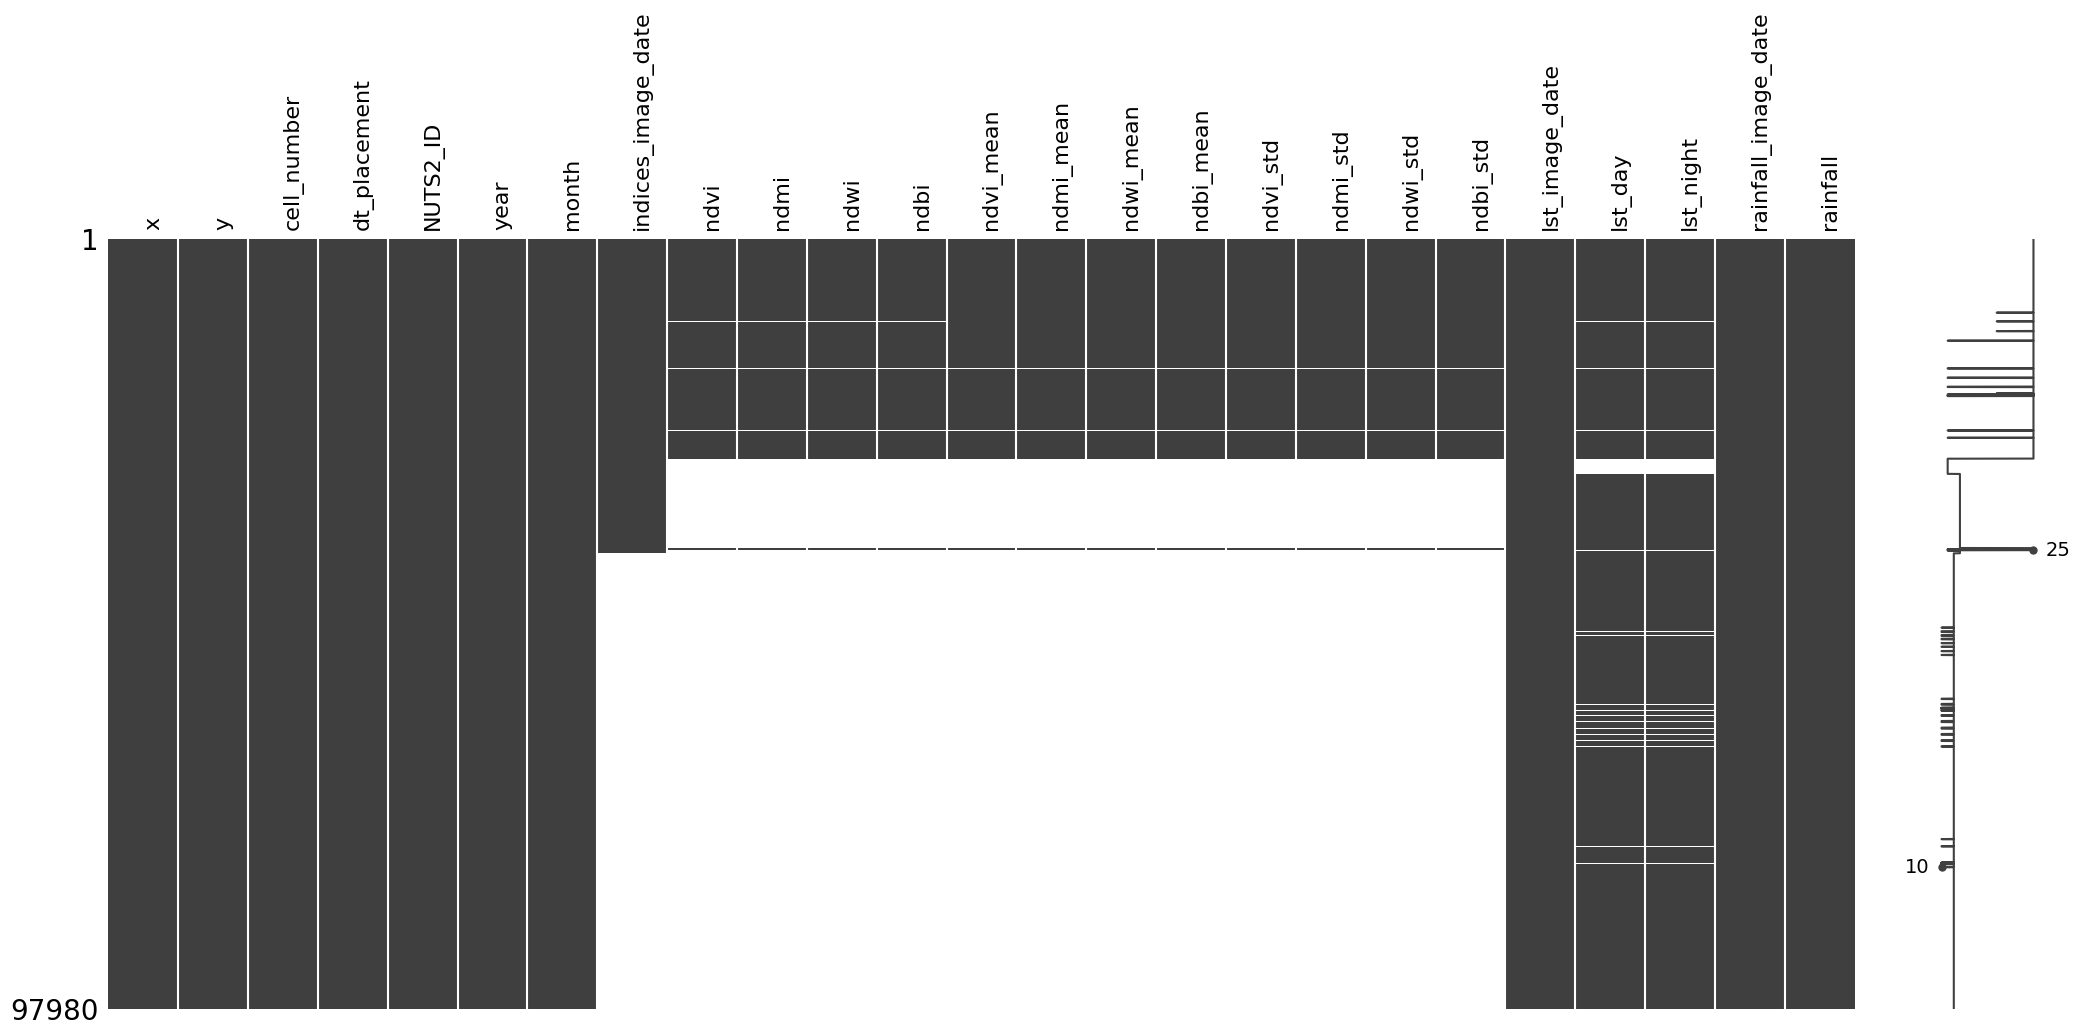

In [15]:
msno.matrix(df, label_rotation=90)

In [16]:
describe_dataframe(df2, remove_zeros=True)

,Column,Missing
7,indices_image_date,59.1753
8,ndvi,71.5554
9,ndmi,71.5554
10,ndwi,71.5554
11,ndbi,71.5554
12,ndvi_mean,71.4636
13,ndmi_mean,71.4636
14,ndwi_mean,71.4636
15,ndbi_mean,71.4636
16,ndvi_std,71.4636


In [17]:
df2.drop(['indices_image_date', 'lst_image_date', 'rainfall_image_date'], axis = 1, inplace=True)

In [18]:
df2.reset_index(drop=True, inplace=True)

In [19]:
df2

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,23.65882,41.33542,0,2024-06-02,EL51,2024,6,0.721511,0.274496,-0.604530,-0.274496,0.731577,0.283857,-0.610010,-0.283857,0.037083,0.028736,0.035048,0.028736,14953.0,14503.0,0.0
1,23.65882,41.33542,0,2024-06-03,EL51,2024,6,0.721511,0.274496,-0.604530,-0.274496,0.731577,0.283857,-0.610010,-0.283857,0.037083,0.028736,0.035048,0.028736,14499.0,14503.0,0.0
2,23.65882,41.33542,0,2024-06-04,EL51,2024,6,0.721511,0.274496,-0.604530,-0.274496,0.731577,0.283857,-0.610010,-0.283857,0.037083,0.028736,0.035048,0.028736,15059.0,14567.0,NaN
3,23.65882,41.33542,0,2024-06-05,EL51,2024,6,0.721511,0.274496,-0.604530,-0.274496,0.731577,0.283857,-0.610010,-0.283857,0.037083,0.028736,0.035048,0.028736,14833.0,14567.0,NaN
4,23.65882,41.33542,0,2024-06-06,EL51,2024,6,0.693297,0.273188,-0.586919,-0.273188,0.703577,0.283014,-0.594945,-0.283014,0.039954,0.029496,0.035281,0.029496,14980.0,14493.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97975,26.58397,41.49712,3261,2024-07-01,EL51,2024,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15641.0,14671.0,NaN
97976,26.60756,41.35339,3262,2024-07-01,EL51,2024,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15733.0,14715.0,NaN
97977,26.60756,41.37135,3263,2024-07-01,EL51,2024,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15712.0,14746.0,NaN
97978,26.60756,41.38932,3264,2024-07-01,EL51,2024,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15713.0,14719.0,NaN


In [20]:
df2.to_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled.csv', encoding='utf-8')